# CNN Notebook: Teaching a Computer to Recognise Clothing

**Level:** beginner. **Time:** about 90 minutes. **Run it:** top to bottom, one cell at a time (Shift + Enter).

**The goal:** build a **CNN (Convolutional Neural Network)** that looks at a small photo and says whether it is a shirt, sneaker, bag, and so on. Then compare it with the plain neural network (ANN) you already know.

**What you will learn**
1. Why ordinary dense networks struggle with images
2. What a *convolution* and *pooling* actually do
3. How to build, train and compare a dense model and a CNN
4. How to look *inside* a CNN and see what it learned
5. How to find where it makes mistakes
6. How to test it on your own photo

> **How to use this notebook:** read the text, run the cell, look at the output, and answer the "Think" questions.

## 1. The idea in plain words

**Problem with a dense network on images:** `Flatten` unrolls the picture into one long line of pixels. The network no longer knows that pixel 1 sits *next to* pixel 2, or *above* pixel 29. It loses the shape.

**A CNN keeps the shape.** It slides a tiny window (a **filter**, here 3 by 3 pixels) across the image, looking for one small pattern: an edge, a corner, a curve.

```
Image  ->  [Conv: find edges]  ->  [Pool: shrink]  ->  [Conv: find shapes]  ->  [Pool]  ->  [Dense: decide]  ->  "Sneaker"
```

| Layer | What it does | Everyday comparison |
|---|---|---|
| **Conv2D** | Slides filters over the image to detect patterns | Scanning a page with a small magnifying glass |
| **MaxPooling2D** | Keeps the strongest signal in each small block, shrinking the image | Squinting to see the big picture |
| **Flatten** | Unrolls the final feature maps into one list | Laying everything on a table |
| **Dense** | Combines the evidence and decides the class | The judge |

**Why it is efficient:** the *same* filter is reused across the whole image, so there are far fewer weights to learn.

**What early and later layers find:** early layers find simple things (edges). Later layers combine them into bigger things (sleeves, soles, handles).

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

tf.keras.utils.set_random_seed(42)   # repeatable results 

## 3. Load the data: Fashion-MNIST

70,000 small grey images (28 by 28 pixels) of clothing, in 10 classes. It has the same format as the MNIST digits you already used, but it is harder, so the difference between models actually shows.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Train images:", x_train.shape)   # (60000, 28, 28)
print("Test images: ", x_test.shape)    # (10000, 28, 28)
print("Pixel range:", x_train.min(), "to", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step
13082624/26421880 ━━━━━━━━━━━━━━━━━━━━ 40s 3us/step

`(60000, 28, 28)` means 60,000 images, each 28 rows by 28 columns. Each pixel is a number from 0 (black) to 255 (white).

## 4. Look at the data first

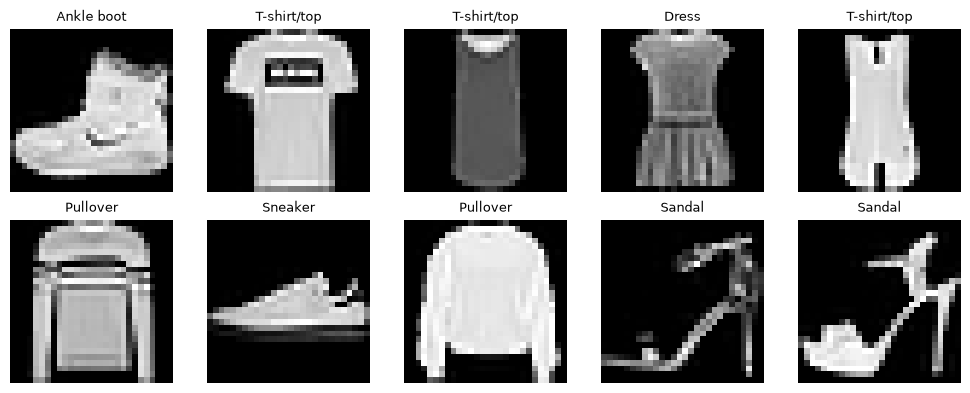

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

**Think:** which two classes look most alike? (T-shirt vs Shirt vs Pullover.) The model will probably struggle there too. We will check at the end.

In [4]:
# Are the classes balanced?
print(np.bincount(y_train))   # should be 6000 each

[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


## 5. Prepare the data

Two small but essential steps:

1. **Scale pixels to 0..1** (divide by 255). Small, similar-sized numbers help training.
2. **Add a channel dimension.** A CNN expects `(height, width, channels)`. Grey images have 1 channel, colour images have 3 (red, green, blue). So `(28, 28)` becomes `(28, 28, 1)`.

We also hold out validation data from the training set. The test set stays untouched until the end.

In [5]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

x_train_cnn = x_train[..., None]    # (60000, 28, 28, 1)
x_test_cnn  = x_test[..., None]

print("Dense-model input shape:", x_train.shape)
print("CNN input shape:        ", x_train_cnn.shape)

Dense-model input shape: (60000, 28, 28)
CNN input shape:         (60000, 28, 28, 1)


> **Most common beginner error:** forgetting `[..., None]`. If you see `expected shape=(None, 28, 28, 1), found shape=(None, 28, 28)`, this is why.

## 6. Model A: the dense baseline (what you already know)

We start here so the CNN has something to beat.

In [6]:
dense = tf.keras.Sequential([
    tf.keras.layers.Input((28, 28)),
    tf.keras.layers.Flatten(),                         # 784 numbers in a line
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),   # 10 classes -> 10 probabilities
])
dense.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
dense.summary()

E0000 00:00:1791222154.806220   13513 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**Loss check:** 10 classes with integer labels (0 to 9) = `Dense(10, softmax)` + `sparse_categorical_crossentropy`. (For yes/no problems it would be `Dense(1, sigmoid)` + `binary_crossentropy`.)

## 7. Model B: the CNN

Read each line with the table from Section 1 in mind.

In [7]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((28, 28, 1)),

    # Block 1: find simple patterns (edges)
    tf.keras.layers.Conv2D(32, 3, activation="relu"),   # 32 filters, each 3x3
    tf.keras.layers.MaxPooling2D(),                     # halve the width and height

    # Block 2: combine them into bigger patterns (shapes)
    tf.keras.layers.Conv2D(64, 3, activation="relu"),   # 64 filters
    tf.keras.layers.MaxPooling2D(),

    # Decision part
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),                       # randomly switch off 30% of neurons while training
    tf.keras.layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**Follow the shape through the network** (look at "Output Shape"):

| Step | Shape | What happened |
|---|---|---|
| Input | 28 x 28 x 1 | the image |
| Conv2D (32 filters, 3x3) | 26 x 26 x 32 | 32 pattern maps (the image shrinks by 2 because a 3x3 window cannot sit on the edge) |
| MaxPooling | 13 x 13 x 32 | halved |
| Conv2D (64 filters) | 11 x 11 x 64 | 64 richer maps |
| MaxPooling | 5 x 5 x 64 | halved again |
| Flatten | 1600 | all values in one line |
| Dense | 10 | one probability per class |

**Parameter check for the first Conv2D:** each filter has 3x3x1 = 9 weights + 1 bias = 10. With 32 filters: 320.

**Think:** compare the total parameters of the CNN with the dense model. Is the CNN bigger?

## 8. Train both models

We use `validation_split=0.1`: Keras sets aside 10% of the training images to check progress after every epoch. EarlyStopping stops when the validation loss stops improving.

In [8]:
def train(model, X, name):
    stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    print(f"--- Training {name} ---")
    return model.fit(X, y_train, validation_split=0.1, epochs=15, batch_size=64,
                     callbacks=[stop], verbose=2)

hist_dense = train(dense, x_train, "Dense")
hist_cnn   = train(cnn, x_train_cnn, "CNN")

--- Training Dense ---
Epoch 1/15
844/844 - 6s - 7ms/step - accuracy: 0.8159 - loss: 0.5291 - val_accuracy: 0.8447 - val_loss: 0.4372
Epoch 2/15
844/844 - 5s - 5ms/step - accuracy: 0.8596 - loss: 0.3956 - val_accuracy: 0.8545 - val_loss: 0.4137
Epoch 3/15
844/844 - 3s - 4ms/step - accuracy: 0.8711 - loss: 0.3552 - val_accuracy: 0.8623 - val_loss: 0.3873
Epoch 4/15
844/844 - 3s - 3ms/step - accuracy: 0.8804 - loss: 0.3284 - val_accuracy: 0.8688 - val_loss: 0.3658
Epoch 5/15
844/844 - 2s - 3ms/step - accuracy: 0.8871 - loss: 0.3074 - val_accuracy: 0.8762 - val_loss: 0.3548
Epoch 6/15
844/844 - 2s - 2ms/step - accuracy: 0.8932 - loss: 0.2910 - val_accuracy: 0.8747 - val_loss: 0.3521
Epoch 7/15
844/844 - 2s - 2ms/step - accuracy: 0.8991 - loss: 0.2771 - val_accuracy: 0.8773 - val_loss: 0.3500
Epoch 8/15
844/844 - 2s - 3ms/step - accuracy: 0.9031 - loss: 0.2663 - val_accuracy: 0.8822 - val_loss: 0.3413
Epoch 9/15
844/844 - 2s - 3ms/step - accuracy: 0.9073 - loss: 0.2549 - val_accuracy: 0.87

## 9. Compare learning curves

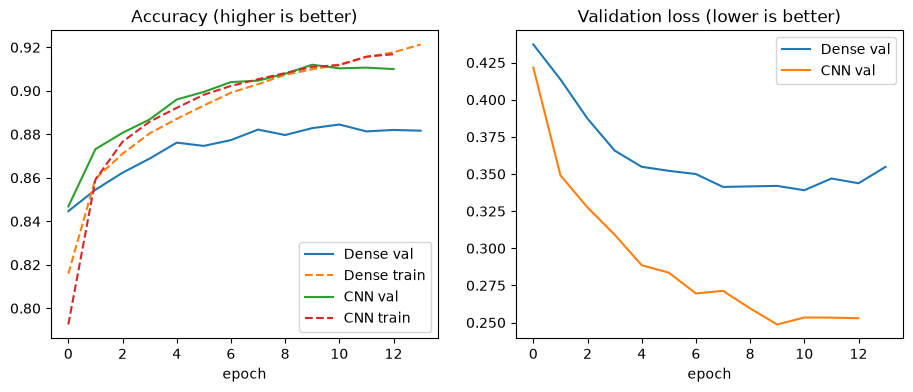

Dense parameters: 101770
CNN parameters:   34826


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for h, name in [(hist_dense, "Dense"), (hist_cnn, "CNN")]:
    ax[0].plot(h.history["val_accuracy"], label=f"{name} val")
    ax[0].plot(h.history["accuracy"], "--", label=f"{name} train")
    ax[1].plot(h.history["val_loss"], label=f"{name} val")
ax[0].set_title("Accuracy (higher is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Validation loss (lower is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

print("Dense parameters:", dense.count_params())
print("CNN parameters:  ", cnn.count_params())

**How to read it**
- A big gap between the dashed (train) and solid (validation) line = **overfitting**.
- Expect the CNN to win by a few points (roughly 90 to 92% vs 87 to 89%). On small 28x28 images the gap is modest. On large, real photos it is much bigger.

## 10. The final exam: test set, used once

In [10]:
dense_loss, dense_acc = dense.evaluate(x_test, y_test, verbose=0)
cnn_loss, cnn_acc     = cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Dense test accuracy: {dense_acc:.3f}")
print(f"CNN test accuracy:   {cnn_acc:.3f}")

Dense test accuracy: 0.878
CNN test accuracy:   0.905


> Do not go back and tweak the model after seeing this number. If you do, the test set has influenced your choices and the score is no longer an honest estimate.

## 11. Where does the CNN make mistakes?

probs shape: (10000, 10)  pred shape: (10000,)


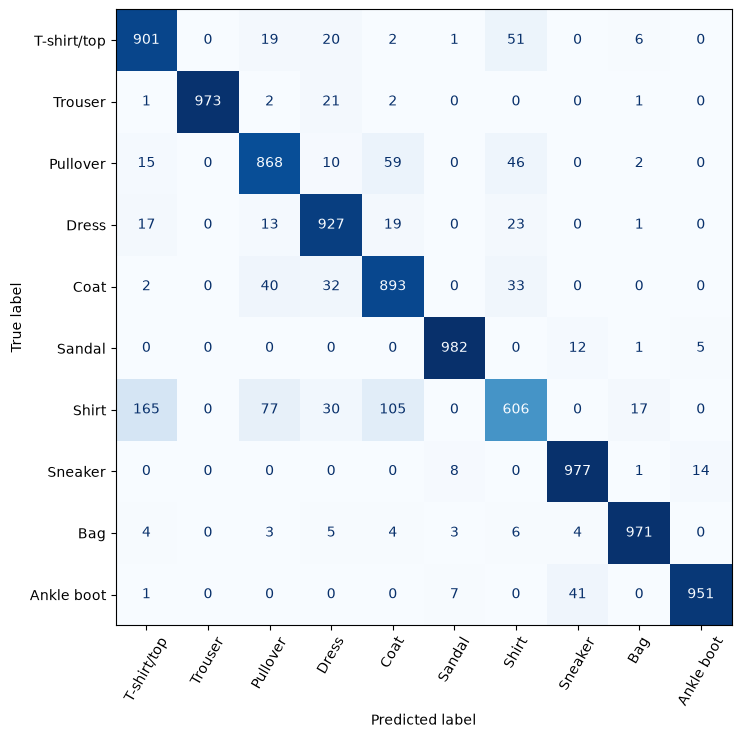

In [11]:
probs = cnn.predict(x_test_cnn, verbose=0)       # shape (10000, 10): 10 probabilities per image
pred = probs.argmax(axis=1)                      # pick the class with the highest probability
print("probs shape:", probs.shape, " pred shape:", pred.shape)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=class_names).plot(
    ax=ax, xticks_rotation=60, cmap="Blues", colorbar=False)
plt.show()

**How to read:** rows are the real class, columns are the prediction. The diagonal is correct. Large numbers off the diagonal are confusions.

**Think:** which pair is confused most? (Usually Shirt vs T-shirt vs Pullover vs Coat.) Would a human also hesitate?

In [12]:
print(classification_report(y_test, pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.90      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.85      0.87      0.86      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.82      0.89      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.79      0.61      0.69      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



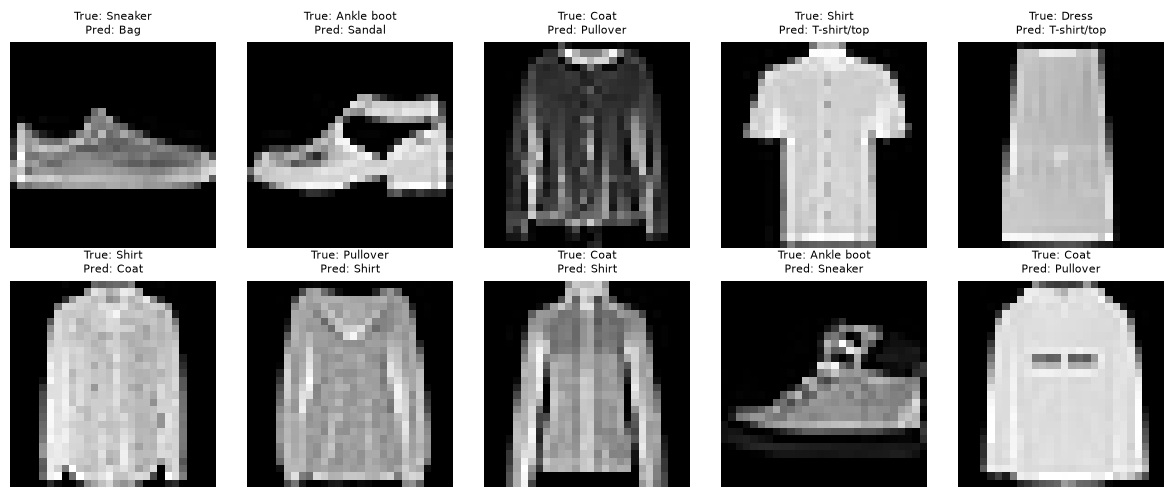

In [13]:
# Look at 10 mistakes
wrong = np.where(pred != y_test)[0][:10]
plt.figure(figsize=(12, 5))
for k, i in enumerate(wrong):
    plt.subplot(2, 5, k + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[pred[i]]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 12. Look inside the CNN

### 12a. The filters (what patterns it searches for)
Each of the 32 first-layer filters is a tiny 3x3 grid of weights. Bright and dark parts show what it reacts to.

In [ ]:
filters = cnn.layers[0].get_weights()[0]       # shape (3, 3, 1, 32)
print("Filter array shape:", filters.shape)

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters[:, :, 0, i], cmap="gray")
    ax.axis("off")
plt.suptitle("The 32 filters learned by the first Conv2D layer")
plt.show()

### 12b. The feature maps (what the filters found in one image)
We pass one image through the first conv layer and see how each filter responded. Bright = "my pattern is here".

In [ ]:
first_conv = tf.keras.Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)

idx = 0                                         # try other numbers
img = x_test_cnn[idx:idx + 1]                   # keep the batch dimension: (1, 28, 28, 1)
maps = first_conv.predict(img, verbose=0)[0]    # (26, 26, 32)

plt.figure(figsize=(3, 3))
plt.imshow(x_test[idx], cmap="gray"); plt.title("Original: " + class_names[y_test[idx]]); plt.axis("off")
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(maps[:, :, i], cmap="viridis")
    ax.axis("off")
plt.suptitle("Feature maps from the first Conv2D layer")
plt.show()

**Think:** some maps light up along edges, some on flat areas. The network was never told to look for edges. It *discovered* that edges are useful.

## 13. Test it on your own picture

Take a photo of a shoe, shirt or bag on a plain background (or download one). Save it in the same folder as the notebook and set `path` below.

**Fashion-MNIST images are a light object on a dark background, centred, 28x28.** Your photo must be converted to match, or the model will fail. This is called **domain shift**: real photos differ from the training data.

In [ ]:
from PIL import Image, ImageOps

path = "my_photo.jpg"          # <-- change this

try:
    im = Image.open(path).convert("L")                  # grey
    im = ImageOps.invert(im)                            # if your object is dark on a light background, invert
    im = ImageOps.fit(im, (28, 28))                     # crop to square and resize
    x = np.array(im, dtype="float32")[None, ..., None] / 255.0     # (1, 28, 28, 1)

    p = cnn.predict(x, verbose=0)[0]
    plt.imshow(im, cmap="gray"); plt.axis("off")
    plt.title(f"{class_names[p.argmax()]} ({p.max():.0%})")
    plt.show()
    print({class_names[i]: round(float(v), 2) for i, v in enumerate(p) if v > 0.05})
except FileNotFoundError:
    print("Photo not found. Put an image in this folder and update `path`.")

**Think:** was it right? Try several photos. Real-world accuracy is almost always lower than the test-set score. Reporting that gap honestly is part of good practice.

## 14. Optional: make it more robust with data augmentation

Augmentation shows the model slightly altered copies of each image (shifted, zoomed) so it learns to cope with imperfect input. It only works during training.

In [ ]:
cnn_aug = tf.keras.Sequential([
    tf.keras.layers.Input((28, 28, 1)),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax"),
])
cnn_aug.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
hist_aug = train(cnn_aug, x_train_cnn, "CNN + augmentation")
print("Test accuracy:", round(cnn_aug.evaluate(x_test_cnn, y_test, verbose=0)[1], 3))

**Think:** the test accuracy may not improve on this clean test set. The benefit shows on *messy* inputs like your own photos. Re-run Section 13 with `cnn_aug` and compare.

## 15. Exercises

1. **Add a third conv block** (`Conv2D(128, 3)` + `MaxPooling2D`). Does accuracy improve? What happens to the parameter count?
2. **Remove Dropout** from the CNN. Does the train/validation gap widen?
3. **Change the filter count** (16 instead of 32). How little can you get away with?
4. **Try the digits** (`tf.keras.datasets.mnist`). Everything stays the same except the dataset. What accuracy do you get?
5. **Repeat with 3 seeds** (`tf.keras.utils.set_random_seed(0, 1, 2)`) and report mean accuracy. Small differences are often noise.
6. **Challenge:** collect 30 of your own photos, test the model, and report the accuracy drop compared to the test set.
6. **Save the model**: Save the model in preparation for deployment

## Cheat sheet

| Concept | One-line summary |
|---|---|
| Convolution | A small filter slides over the image detecting a pattern |
| Filter / kernel | The tiny grid of weights (e.g. 3x3) that gets learned |
| Feature map | The filter's output: where it found its pattern |
| Pooling | Shrinks the image, keeps the strongest signals |
| Channel | Colour layers: 1 for grey, 3 for RGB |
| Flatten | Unrolls feature maps into one list for the Dense layers |
| Softmax | Turns 10 scores into 10 probabilities that sum to 1 |
| Overfitting | Great on train, worse on validation |
| Domain shift | Real-world input differs from training data, so accuracy drops |
| Augmentation | Random shifts/zooms during training to make the model robust |

**Next lesson:** transfer learning. Reuse a CNN already trained on millions of photos (MobileNetV2) and adapt it to your own images with far less data.